# Swiss prep notebook 2: Dasymetric employment

Distributes Swiss municipal employment totals (BFS STATENT, public,
3-sector NOGA) across OSM building footprints, producing a per-building
employment estimate. Result feeds the cell-level aggregation in
notebook 3 and is the destination weight for "jobs"-type accessibility
metrics in the main analysis.

**Why dasymetric.** BFS STATENT publishes employment at three spatial
resolutions:

- **Hectare** (100 m grid) — highest fidelity, but **restricted access**
  (available upon application from BFS). Using this would skip the
  dasymetric step entirely *within Switzerland* — but the moment scope
  expands across the border (Basel/Mulhouse, Geneva/Annemasse, Ticino/
  Lombardy, Bodensee), dasymetric mapping becomes necessary anyway,
  because no comparable hectare dataset exists for neighbouring
  countries. Keeping the dasymetric pipeline as the canonical path
  means cross-border extension is a straight-line extrapolation rather
  than a different methodology.
- **Municipal aggregate** — public, no restrictions. What we use here.
- **Cantonal / national totals** — also public, too coarse for
  accessibility.

This notebook chooses the public municipal path so the full pipeline is
reproducible without data-access negotiations. Any data layer in aperta
is inherently swappable: if you have the restricted hectare data, drop
it directly in place of `employment_per_building.gpkg` and skip this
notebook.

**FTEs, not headcounts.** We use STATENT's *Vollzeitäquivalente*
(full-time equivalent) observation unit rather than *Beschäftigte*
(employed persons). FTEs measure job opportunities — a workplace
with 10 half-time positions counts as 5 FTEs and is the right
denominator for accessibility-to-jobs metrics (you want labour demand,
not headcount).

**Method (3-sector NOGA).** For each of primary / secondary / tertiary:

1. **Predict** unscaled per-building employment as
   `pred_i_s = w_{tag(i), s} · area_i`, where `w` is a literature-based
   prior of FTE per m² of footprint per OSM building tag per sector
   (e.g. `building=industrial` weights only the secondary sector;
   `building=office` only tertiary; `building=farm` only primary).
2. **Rescale per municipality** so `Σ pred_i_s over buildings in m = BFS_s_m`.
   Per-muni rescaling means the relative weights between OSM tags within
   a sector matter; absolute magnitudes don't — the rescale absorbs them.
3. **Adjust for partial municipalities.** Border munis intersect
   `dest_polygon` only partially. We scale their BFS totals by
   `area_inside / area_total` to avoid overcounting in the buildings
   we have. Simple, conservative; assumes uniform within-muni
   distribution (it isn't, but the bias is small at our scope).

**Cross-border note.** All munis at the default Bern + 25 km scope are
inside Switzerland, so we don't need cross-border extrapolation yet.
The notebook is structured to make the future extension easy: the
fitted per-OSM-tag coefficients are saved separately and could be
applied to non-Swiss OSM buildings (which have no BFS anchor) when the
scope expands.

In [1]:
import warnings
import zipfile
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from pyaxis import pyaxis

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('../data/prepared')
CRS_METRIC = 'EPSG:2056'   # Swiss LV95

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Load inputs from notebook 1

In [2]:
dest_polygon = gpd.read_file(PREPARED_DIR / 'dest_polygon.gpkg').geometry.iloc[0]
buildings = gpd.read_file(PREPARED_DIR / 'buildings.gpkg')
print(f"Destination polygon: {dest_polygon.area / 1e6:.1f} km²")
print(f"Buildings: {len(buildings):,}")
print(f"Building tag counts (top 10):")
print(buildings['building'].value_counts().head(10).to_string())

Destination polygon: 6562.2 km²
Buildings: 554,135
Building tag counts (top 10):
building
yes            272995
residential    124149
garage          27449
barn            21309
house           20869
farm            19507
apartments      18938
shed             8889
roof             7839
detached         4645


## 2. Download BFS STATENT — municipal employment totals (.px)

`px-x-0602010000_102.px`: "Arbeitsstätten und Beschäftigte nach Jahr,
Gemeinde, Wirtschaftssektor und Beobachtungseinheit." Annual series
2011–2023. We use the most recent year + the *3-sector NOGA*
(`Primärsektor`, `Sekundärer Sektor`, `Tertiärer Sektor`) + the
observation unit `Vollzeitäquivalente` (full-time-equivalent jobs).

In [3]:
STATENT_URL = 'https://dam-api.bfs.admin.ch/hub/api/dam/assets/36066478/master'
STATENT_PATH = PREPARED_DIR / 'bfs_statent_employment.px'
STATENT_YEAR = '2023'

if not STATENT_PATH.exists():
    print(f"Downloading STATENT (.px, ~5 MB)...")
    r = requests.get(STATENT_URL, timeout=60)
    r.raise_for_status()
    STATENT_PATH.write_bytes(r.content)
    print(f"  Saved to {STATENT_PATH}")

  Saved to ../data/prepared/bfs_statent_employment.px


In [4]:
# Parse the .px file. Charset is iso-8859-15 per the file header.
px = pyaxis.parse(uri=str(STATENT_PATH), encoding='iso-8859-15')
statent_raw = px['DATA']
print(f"Raw STATENT: {len(statent_raw):,} rows × {len(statent_raw.columns)} cols")
print(f"  Years available: {sorted(statent_raw['Jahr'].unique())}")
print(f"  Sectors: {list(statent_raw['Wirtschaftssektor'].unique())}")
print(f"  Observation units: {list(statent_raw['Beobachtungseinheit'].unique())}")

Multilingual PX file
Raw STATENT: 777,868 rows × 5 cols
  Years available: ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
  Sectors: ['Wirtschaftssektor - Total', 'Primärsektor', 'Sekundärer Sektor', 'Tertiärer Sektor']
  Observation units: ['Arbeitsstätten', 'Beschäftigte', 'Beschäftigte Frauen', 'Beschäftigte Männer', 'Vollzeitäquivalente', 'Vollzeitäquivalente Frauen', 'Vollzeitäquivalente Männer']


In [5]:
# Filter to: latest year, "Beschäftigte" only, 3 sectors only (drop the Total
# row — we reconstruct totals at the end). Drop the "Schweiz" row (national
# aggregate; not a municipality).
SECTOR_RENAME = {
    'Primärsektor':       'primary',
    'Sekundärer Sektor':  'secondary',
    'Tertiärer Sektor':   'tertiary',
}

statent = statent_raw[
    (statent_raw['Jahr'] == STATENT_YEAR)
    & (statent_raw['Beobachtungseinheit'] == 'Vollzeitäquivalente')
    & (statent_raw['Wirtschaftssektor'].isin(SECTOR_RENAME.keys()))
    & (statent_raw['Gemeinde'] != 'Schweiz')
].copy()

# Extract bfs_number from the 'Gemeinde' column (format: '{bfs_number} {name}').
statent[['bfs_number', 'name']] = statent['Gemeinde'].str.split(' ', n=1, expand=True)
statent['bfs_number'] = statent['bfs_number'].astype(int)
statent['sector'] = statent['Wirtschaftssektor'].map(SECTOR_RENAME)
# BFS marks privacy-suppressed values (small munis where a single employer
# would be identifiable) with the literal string '"......"'. `to_numeric`
# with `errors='coerce'` turns those into NaN; we then treat them as 0
# FTE in that (muni × sector) entry — by definition these are very small
# counts (suppression threshold is typically <3 employers), so the bias
# is negligible at our scope.
fte_numeric = pd.to_numeric(statent['DATA'], errors='coerce')
n_suppressed = int(fte_numeric.isna().sum())
print(f"  Privacy-suppressed (muni × sector) entries: {n_suppressed:,} "
      f"({n_suppressed/len(statent)*100:.1f} %)")
statent['employment'] = fte_numeric.fillna(0.0).astype(float)
statent = statent[['bfs_number', 'name', 'sector', 'employment']]

# Pivot to wide form: one row per muni, columns = primary/secondary/tertiary.
emp_by_muni = (statent
               .pivot_table(index=['bfs_number', 'name'],
                            columns='sector', values='employment',
                            aggfunc='sum', fill_value=0.0)
               .reset_index())
emp_by_muni['total'] = (emp_by_muni['primary']
                        + emp_by_muni['secondary']
                        + emp_by_muni['tertiary'])
print(f"BFS {STATENT_YEAR}: {len(emp_by_muni):,} municipalities, "
      f"{emp_by_muni['total'].sum():,.0f} FTE (3-sector sum)")

  Privacy-suppressed (muni × sector) entries: 392 (6.1 %)
BFS 2023: 2,136 municipalities, 4,354,871 FTE (3-sector sum)


## 3. Download swissBOUNDARIES3D — municipal polygons

swisstopo's open-data product. The GeoPackage bundles all admin levels;
we only need the municipality layer (`tlm_hoheitsgebiet`). CRS is
already LV95 (EPSG:2056). Geometries are MultiPolygon Z — we drop the
Z dimension since 2D suffices for spatial joins to buildings.

In [6]:
SB3D_URL = (
    'https://data.geo.admin.ch/ch.swisstopo.swissboundaries3d/'
    'swissboundaries3d_2024-01/'
    'swissboundaries3d_2024-01_2056_5728.gpkg.zip'
)
SB3D_ZIP_PATH = PREPARED_DIR / 'swissBOUNDARIES3D.gpkg.zip'
SB3D_GPKG_PATH = PREPARED_DIR / 'swissBOUNDARIES3D_1_5_LV95_LN02.gpkg'

if not SB3D_ZIP_PATH.exists() and not SB3D_GPKG_PATH.exists():
    print(f"Downloading swissBOUNDARIES3D (.gpkg.zip, ~36 MB)...")
    r = requests.get(SB3D_URL, timeout=120)
    r.raise_for_status()
    SB3D_ZIP_PATH.write_bytes(r.content)
    print(f"  Saved to {SB3D_ZIP_PATH}")

if not SB3D_GPKG_PATH.exists():
    print("Unzipping...")
    with zipfile.ZipFile(SB3D_ZIP_PATH, 'r') as z:
        for member in z.namelist():
            if member.endswith('.gpkg'):
                z.extract(member, PREPARED_DIR)
    SB3D_ZIP_PATH.unlink(missing_ok=True)

  Saved to ../data/prepared/swissBOUNDARIES3D.gpkg.zip
Unzipping...


In [7]:
# Load + clip to munis intersecting the destination polygon. Drop Z dimension.
munis_all = gpd.read_file(SB3D_GPKG_PATH, layer='tlm_hoheitsgebiet')
munis_all['geometry'] = munis_all.geometry.force_2d()

dest_gdf = gpd.GeoDataFrame(geometry=[dest_polygon], crs=CRS_METRIC)
munis = gpd.sjoin(
    munis_all[['bfs_nummer', 'name', 'kantonsnummer', 'gem_flaeche', 'geometry']],
    dest_gdf, how='inner', predicate='intersects',
).rename(columns={'bfs_nummer': 'bfs_number'}).drop(columns=['index_right'])

# `gem_flaeche` from swissBOUNDARIES3D is in ha (per the spec); convert to m².
munis['area_total_m2'] = munis['gem_flaeche'] * 10_000

# Area of each muni inside the destination polygon (used to scale BFS totals
# for partial munis at the boundary).
munis['area_inside_m2'] = munis.geometry.intersection(dest_polygon).area
munis['inside_ratio'] = (munis['area_inside_m2']
                         / munis['area_total_m2']).clip(0, 1)

print(f"Munis intersecting dest_polygon: {len(munis):,}")
print(f"  Fully inside (>99 %):  "
      f"{(munis['inside_ratio'] > 0.99).sum():,}")
print(f"  Partial (border):      "
      f"{((munis['inside_ratio'] > 0.01) & (munis['inside_ratio'] <= 0.99)).sum():,}")
print(f"  Marginal sliver (≤1 %):"
      f" {(munis['inside_ratio'] <= 0.01).sum():,}")

Munis intersecting dest_polygon: 549
  Fully inside (>99 %):  463
  Partial (border):      82
  Marginal sliver (≤1 %): 4


## 4. Join buildings to municipalities

Each building is assigned to the muni containing its centroid. At the
default Bern + 25 km scope every building should land inside a Swiss
muni; assertion enforces this and will be relaxed when the scope
expands across the border.

In [8]:
# Build a points GeoDataFrame from the building centroids for the sjoin.
b_pts = gpd.GeoDataFrame(
    {'building_id': buildings.index, 'building_tag': buildings['building']},
    geometry=buildings.geometry.centroid,
    crs=buildings.crs,
)
joined = gpd.sjoin(
    b_pts, munis[['bfs_number', 'geometry']],
    how='left', predicate='within',
).drop(columns=['index_right'])
unmatched = joined['bfs_number'].isna().sum()
print(f"Buildings: {len(buildings):,}, unmatched (no Swiss muni): "
      f"{unmatched:,} ({unmatched/len(buildings)*100:.2f} %)")
assert unmatched / len(buildings) < 0.01, (
    f"More than 1 % of buildings have no muni assignment ({unmatched:,}). "
    f"At the default Bern scope this shouldn't happen — when expanding across "
    f"the border, switch to the cross-border-coefficient path documented "
    f"in the notebook header.")

# Carry bfs_number + tag + area back onto `buildings`.
buildings = buildings.copy()
buildings['bfs_number'] = joined['bfs_number'].values
buildings = buildings.dropna(subset=['bfs_number'])
buildings['bfs_number'] = buildings['bfs_number'].astype(int)

Buildings: 554,135, unmatched (no Swiss muni): 0 (0.00 %)


## 5. Per-OSM-tag × per-sector coefficient priors

FTE per m² of building footprint, broken down by (OSM `building` tag,
NOGA sector). Within a sector, relative weights between tags matter
(a tag with weight 5 attracts 5× more employment than weight 1 in the
same sector / municipality); absolute magnitudes are absorbed by the
per-muni rescaling. Tag values not listed here fall back to
`_FALLBACK_COEFFS`.

These are starting priors — they encode "where each sector typically
locates" rather than calibrated per-square-metre densities. The
calibration notebook (planned) will fit them from MZMV / MOBIS data.

In [9]:
# (primary, secondary, tertiary) coefficients per OSM `building` tag.
COEFFS = {
    # Primary sector — agriculture & forestry buildings.
    'farm':              (1.0, 0.0, 0.0),
    'farm_auxiliary':    (1.0, 0.0, 0.0),
    'barn':              (0.5, 0.0, 0.0),
    'stable':            (0.3, 0.0, 0.0),
    'cowshed':           (0.5, 0.0, 0.0),
    'sty':               (0.3, 0.0, 0.0),
    'greenhouse':        (0.5, 0.0, 0.0),
    'silo':              (0.2, 0.0, 0.0),

    # Secondary sector — industry, manufacturing, construction.
    'industrial':        (0.0, 1.0, 0.0),
    'factory':           (0.0, 1.0, 0.0),
    'manufacture':       (0.0, 1.0, 0.0),
    'warehouse':         (0.0, 0.5, 0.0),

    # Mostly tertiary, some secondary (workshops etc.).
    'commercial':        (0.0, 0.2, 1.0),
    'service':           (0.0, 0.2, 0.5),

    # Tertiary — services, retail, offices, hospitality, education, health.
    'office':            (0.0, 0.0, 3.0),
    'retail':            (0.0, 0.0, 2.0),
    'supermarket':       (0.0, 0.0, 2.0),
    'kiosk':             (0.0, 0.0, 1.0),
    'hospital':          (0.0, 0.0, 2.5),
    'clinic':            (0.0, 0.0, 2.0),
    'school':            (0.0, 0.0, 1.5),
    'kindergarten':      (0.0, 0.0, 1.0),
    'university':        (0.0, 0.0, 2.0),
    'college':           (0.0, 0.0, 2.0),
    'hotel':             (0.0, 0.0, 1.0),
    'civic':             (0.0, 0.0, 2.0),
    'public':            (0.0, 0.0, 2.0),
    'government':        (0.0, 0.0, 2.0),
    'museum':            (0.0, 0.0, 1.0),
    'religious':         (0.0, 0.0, 0.3),
    'chapel':            (0.0, 0.0, 0.1),
    'church':            (0.0, 0.0, 0.2),

    # Residential — minor home-business + mixed-use contributions.
    'apartments':        (0.0, 0.05, 0.2),
    'residential':       (0.0, 0.02, 0.1),
    'house':             (0.0, 0.02, 0.1),
    'detached':          (0.0, 0.02, 0.1),
    'terrace':           (0.0, 0.02, 0.1),
    'semidetached_house': (0.0, 0.02, 0.1),
    'dormitory':         (0.0, 0.0, 0.1),

    # Non-employment structures.
    'garage':            (0.0, 0.0, 0.0),
    'garages':           (0.0, 0.0, 0.0),
    'carport':           (0.0, 0.0, 0.0),
    'shed':              (0.05, 0.0, 0.0),
    'roof':              (0.0, 0.0, 0.0),
    'hut':               (0.0, 0.0, 0.0),
    'cabin':             (0.0, 0.0, 0.0),
}
# Generic `building=yes` — broad fallback. Captures everything from sheds
# to office towers; the per-muni rescale absorbs systematic bias.
_FALLBACK_COEFFS = (0.05, 0.1, 0.5)
SECTORS = ('primary', 'secondary', 'tertiary')

# Vectorised coefficient lookup.
coef_df = pd.DataFrame.from_dict(
    COEFFS, orient='index', columns=list(SECTORS))
coef_df.index.name = 'building_tag'
print(f"Coefficient priors defined for {len(coef_df):,} OSM building tags.")

Coefficient priors defined for 46 OSM building tags.


## 6. Predict per-building employment per sector (unscaled)

In [10]:
# Per-building prior. Buildings with tags not in COEFFS fall back to
# `_FALLBACK_COEFFS`. `area_m2` already on the buildings GeoDataFrame.
for sec_idx, sec in enumerate(SECTORS):
    buildings[f'_w_{sec}'] = (
        buildings['building']
        .map({tag: coefs[sec_idx] for tag, coefs in COEFFS.items()})
        .fillna(_FALLBACK_COEFFS[sec_idx])
    )
    buildings[f'_pred_{sec}'] = buildings[f'_w_{sec}'] * buildings['area_m2']

## 7. Per-municipality × per-sector rescaling

For each (muni, sector), compute the rescale factor that makes the sum
of predicted employment over buildings in that muni equal to the BFS
total for that (muni, sector). Adjust BFS totals downward for partial
munis by the area fraction inside `dest_polygon` (since the corresponding
buildings outside the polygon aren't in our `buildings` set).

In [11]:
# Build the (muni, sector) target table: BFS total × inside_ratio.
emp_for_munis = munis[['bfs_number', 'inside_ratio']].merge(
    emp_by_muni[['bfs_number', 'primary', 'secondary', 'tertiary']],
    on='bfs_number', how='left',
)
# Munis missing in BFS (rare — e.g. very recent mergers) → 0 employment;
# rescale factor for them will be 0 / pred = 0, which is correct.
emp_for_munis[list(SECTORS)] = (
    emp_for_munis[list(SECTORS)].fillna(0).astype(float)
    .mul(emp_for_munis['inside_ratio'], axis=0)
)

# Per-muni sum of predicted employment per sector (over OUR buildings).
pred_by_muni = (
    buildings.groupby('bfs_number')[[f'_pred_{s}' for s in SECTORS]].sum()
    .rename(columns={f'_pred_{s}': s for s in SECTORS})
)

# Rescale factor per (muni, sector) = target / predicted. Where predicted
# is zero (no employment-relevant buildings in muni), set factor to 0 to
# avoid div-by-zero — the BFS total for that (muni, sector) gets dropped
# (no buildings to attach it to). Logged below for transparency.
scale = emp_for_munis.set_index('bfs_number')[list(SECTORS)].div(
    pred_by_muni, axis=0, level=0,
).replace([np.inf, -np.inf], 0).fillna(0)

# Apply scale to each building's prediction.
for sec in SECTORS:
    factor = buildings['bfs_number'].map(scale[sec])
    buildings[f'employment_{sec}'] = buildings[f'_pred_{sec}'] * factor

buildings['employment_total'] = (
    buildings['employment_primary']
    + buildings['employment_secondary']
    + buildings['employment_tertiary']
)

## 8. Validation

In [12]:
# Per-muni reconstructed sums vs BFS targets.
reconstructed = (
    buildings.groupby('bfs_number')[
        [f'employment_{s}' for s in SECTORS]
    ].sum().rename(columns={f'employment_{s}': s for s in SECTORS})
)
target = emp_for_munis.set_index('bfs_number')[list(SECTORS)]
diff = (reconstructed - target).abs()

# Munis where target > 0 but reconstructed = 0 (no employment-eligible
# buildings) — employment was DROPPED. Log and show the magnitude.
dropped_mask = (target.sum(axis=1) > 0) & (reconstructed.sum(axis=1) == 0)
dropped = target[dropped_mask].sum()
print("--- Reconstructed vs BFS totals (across all munis × sectors) ---")
print(f"  Σ BFS target (scope-scaled): {target.sum().to_dict()}")
print(f"  Σ reconstructed:             {reconstructed.sum().to_dict()}")
print(f"  Max abs diff per muni-sector: {diff.max().to_dict()}")
print(f"  Σ dropped (no eligible buildings in muni): "
      f"{dropped.to_dict()}")

--- Reconstructed vs BFS totals (across all munis × sectors) ---
  Σ BFS target (scope-scaled): {'primary': 27173.27696566842, 'secondary': 183280.6459243168, 'tertiary': 511703.27684594295}
  Σ reconstructed:             {'primary': 27172.910135361468, 'secondary': 183278.78702758157, 'tertiary': 511701.0359760569}
  Max abs diff per muni-sector: {'primary': 5.684341886080802e-14, 'secondary': 9.094947017729282e-13, 'tertiary': 1.8189894035458565e-12}
  Σ dropped (no eligible buildings in muni): {'primary': 0.0, 'secondary': 0.0, 'tertiary': 0.0}


/var/folders/wq/r5yds3q55y14syyjw53z9xg80000gn/T/ipykernel_98414/620096099.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dropped = target[dropped_mask].sum()


Visualise: per-cell employment density (sum of FTE per cell or
similar — here we use a simple hexbin overlay on the destination polygon
for a quick eyeball check).

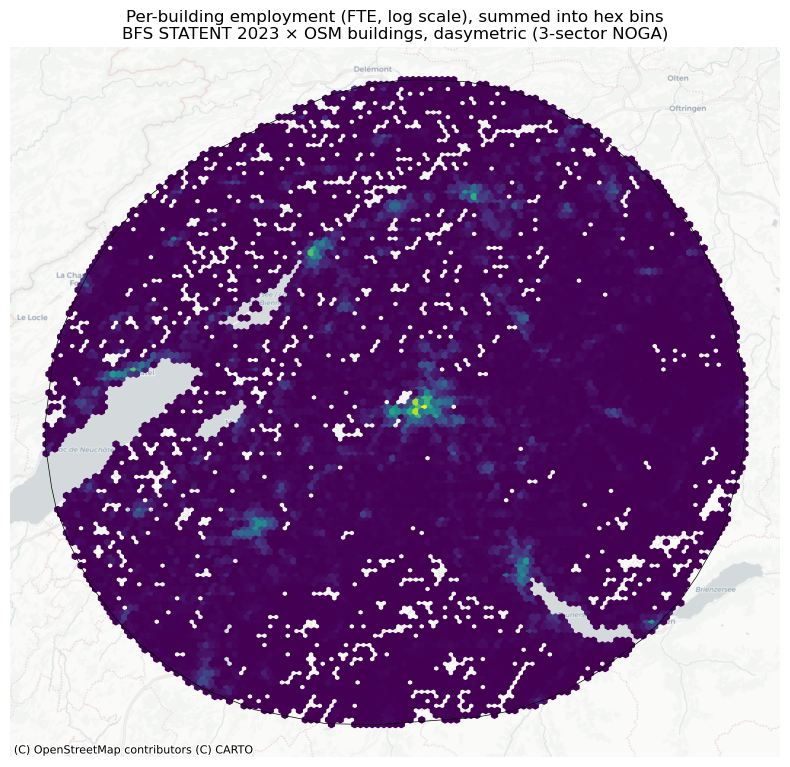

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
# Hexbin needs point coords; buildings are polygon footprints, so use centroids.
b_centroids = buildings.geometry.centroid
buildings['employment_total_log'] = np.log(buildings['employment_total'] + 1)
ax.hexbin(
    b_centroids.x, b_centroids.y,
    C=buildings['employment_total_log'], reduce_C_function=np.sum,
    gridsize=120, cmap='viridis', mincnt=0.1,
)
gpd.GeoSeries([dest_polygon], crs=CRS_METRIC).boundary.plot(
    ax=ax, color='black', linewidth=0.5,
)
cx.add_basemap(
    ax, source=cx.providers.CartoDB.Positron(r='@2x'), crs=CRS_METRIC,
)
ax.set_title(
    f"Per-building employment (FTE, log scale), summed into hex bins\n"
    f"BFS STATENT {STATENT_YEAR} × OSM buildings, dasymetric (3-sector NOGA)"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 9. Save outputs

- `employment_per_building.gpkg` — geometry + `employment_primary`,
  `_secondary`, `_tertiary`, `_total` columns. Consumed by notebook 3.
- `employment_per_tag_coefficients.csv` — the *prior* coefficients used.
  Currently the same as the manually-defined priors above; when a
  calibration step is added (separate notebook), the *fitted* coefficients
  would be saved here. Reusable across borders for cross-border
  extrapolation when scope expands beyond Switzerland.

In [14]:
out_cols = ['building', 'area_m2', 'bfs_number',
            'employment_primary', 'employment_secondary',
            'employment_tertiary', 'employment_total', 'geometry']
buildings[out_cols].to_file(
    PREPARED_DIR / 'employment_per_building.gpkg', driver='GPKG',
)
coef_df.to_csv(PREPARED_DIR / 'employment_per_tag_coefficients.csv')

print(f"\nSaved:")
print(f"  {PREPARED_DIR / 'employment_per_building.gpkg'}")
print(f"  {PREPARED_DIR / 'employment_per_tag_coefficients.csv'}")
print(f"\nTotal FTE distributed: "
      f"{buildings['employment_total'].sum():,.0f}")

INFO:pyogrio._io:Created 554,135 records



Saved:
  ../data/prepared/employment_per_building.gpkg
  ../data/prepared/employment_per_tag_coefficients.csv

Total FTE distributed: 722,153
